# 🎓 Day 2 — Deep Learning (LSTM) | Alok Kumar Dwivedi
## AI-Powered Student Performance & Dropout Predictor
### FDP 5-Day Academic AI Project

**Goal:** Build a 2-layer LSTM to read a student's semester SGPA sequence and predict next-semester CGPA + trend.

**Output:** `predict_cgpa([7.2, 6.8, 6.1, 5.9])` → `{'predicted_cgpa': 5.6, 'trend': 'DECLINING'}`

---
**Dataset:** `mstz/student-performance` (same as Day 1) — G1/G2/G3 used as 3-semester time series  
**Augmentation:** Gaussian noise → 2000+ synthetic sequences (no extra download)  
**Training:** Colab T4 GPU — completes in 5–10 minutes


## ⚙️ Cell 1 — Verify GPU
Go to: Runtime → Change runtime type → T4 GPU

In [1]:
import torch
import tensorflow as tf

print('CUDA available:', torch.cuda.is_available())
print('TF GPU devices:', tf.config.list_physical_devices('GPU'))
!nvidia-smi

CUDA available: True
TF GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri Apr 10 07:04:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                   

In [2]:
# Cell 2 — Install packages
!pip install -q datasets transformers huggingface_hub accelerate
!pip install -q tensorflow numpy scikit-learn matplotlib
print('All packages installed ✓')

All packages installed ✓


In [4]:
# Cell 3 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/fdp_student_ai', exist_ok=True)
SAVE_DIR = '/content/drive/MyDrive/fdp_student_ai'
print('Drive mounted. Save directory ready:', SAVE_DIR)

Mounted at /content/drive
Drive mounted. Save directory ready: /content/drive/MyDrive/fdp_student_ai


## 📊 Cell 4 — Load & Prepare Time-Series Data

Using the same `mstz/student-performance` dataset — G1, G2, G3 grades scaled to 10-point SGPA.

## 🔧 Cell 5 — Augment to 2000+ Sequences (Gaussian Noise)

✅ Total sequences: 5000 | Shape: (5000, 6)
Min SGPA: 0.00 | Max SGPA: 10.00 | Mean: 7.02


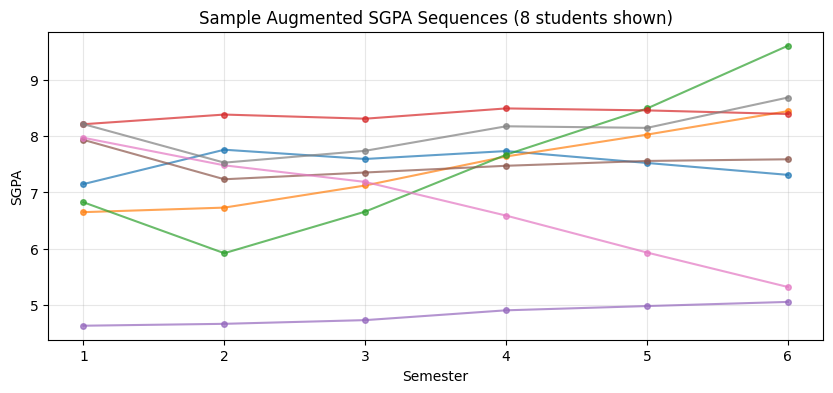

In [8]:
np.random.seed(42)
all_sequences = []

for _, row in df.iterrows():
    base = [row['S1'], row['S2'], row['S3']]

    for _ in range(5):  # 5 augmented versions per student
        # Add small Gaussian noise to base 3 semesters
        noise = np.random.normal(0, 0.3, 3)
        seq = np.clip(np.array(base) + noise, 0, 10)

        # Extend to 6 semesters by following the trend
        trend = seq[-1] - seq[-2]  # last observed trend
        s4 = np.clip(seq[-1] + trend + np.random.normal(0, 0.2), 0, 10)
        s5 = np.clip(s4      + trend + np.random.normal(0, 0.2), 0, 10)
        s6 = np.clip(s5      + trend + np.random.normal(0, 0.2), 0, 10)

        full_seq = list(seq) + [s4, s5, s6]
        all_sequences.append(full_seq)

seqs = np.array(all_sequences)  # shape: (N, 6)
print(f'✅ Total sequences: {len(seqs)} | Shape: {seqs.shape}')
print(f'Min SGPA: {seqs.min():.2f} | Max SGPA: {seqs.max():.2f} | Mean: {seqs.mean():.2f}')

# Quick plot of sample sequences
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.plot(range(1, 7), all_sequences[i*50], alpha=0.7, marker='o', markersize=4)
plt.xlabel('Semester'); plt.ylabel('SGPA')
plt.title('Sample Augmented SGPA Sequences (8 students shown)')
plt.grid(alpha=0.3)
plt.show()

## 🔗 Cell 6 — Create Sliding-Window Sequences (X=4 sems → y=5th)

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))
seqs_scaled = scaler.fit_transform(seqs)  # scale entire dataset

SEQ_LEN = 4  # look at 4 past semesters to predict the 5th
X_seq, y_seq = [], []

for seq in seqs_scaled:
    for i in range(len(seq) - SEQ_LEN):
        X_seq.append(seq[i : i + SEQ_LEN])
        y_seq.append(seq[i + SEQ_LEN])

# LSTM expects shape: (samples, timesteps, features)
X_seq = np.array(X_seq).reshape(-1, SEQ_LEN, 1)
y_seq = np.array(y_seq)

# Train/test split (80/20)
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f'X_train shape: {X_train.shape}  | y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test.shape}   | y_test shape:  {y_test.shape}')
print(f'Total training samples: {len(X_train)}')

X_train shape: (8000, 4, 1)  | y_train shape: (8000,)
X_test shape:  (2000, 4, 1)   | y_test shape:  (2000,)
Total training samples: 8000


## 🧠 Cell 7 — Build & Train 2-Layer LSTM on T4 GPU

In [10]:
# Build 2-layer LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # regression output — predict next scaled SGPA
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1, min_lr=1e-6),
]

print('\nTraining LSTM on T4 GPU (should take 5–10 minutes)...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print('\n✅ Training complete!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM on T4 GPU (should take 5–10 minutes)...
Epoch 1/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0480 - mae: 0.1543 - val_loss: 0.0151 - val_mae: 0.0963 - learning_rate: 0.0010
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0173 - mae: 0.1045 - val_loss: 0.0119 - val_mae: 0.0864 - learning_rate: 0.0010
Epoch 3/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0118 - mae: 0.0864 - val_loss: 0.0045 - val_mae: 0.0527 - learning_rate: 0.0010
Epoch 4/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0063 - mae: 0.0628 - val_loss: 0.0048 - val_mae: 0.0566 - learning_rate: 0.0010
Epoch 5/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0048 - mae: 0.0548 - val_loss: 0.0025 - val_mae: 0.0399 - learning_rate: 0.0010
Epoch 6/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0035 - mae: 0.0464 - val_loss: 0.0024 - val_mae: 0.0400 - learning_rate: 0.0010
Epoch 7/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0029 - mae: 0.0424 - val_loss: 

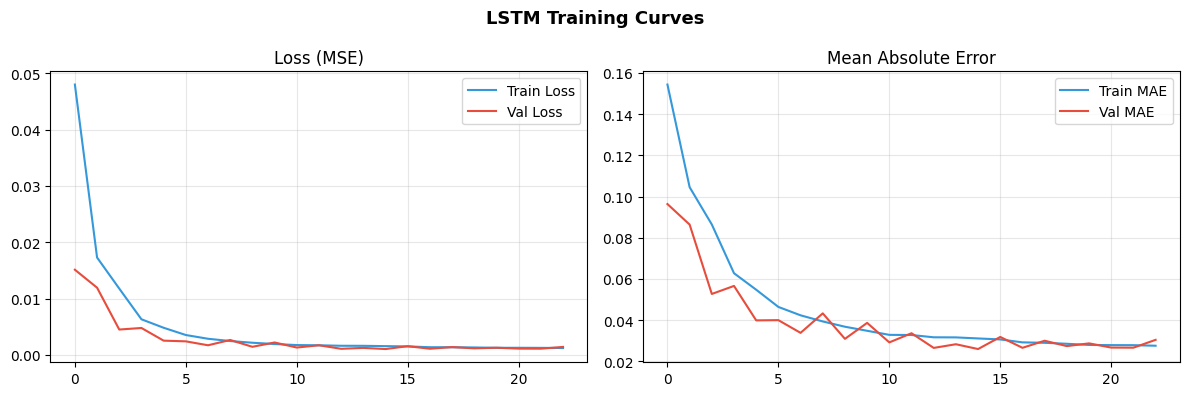

In [11]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LSTM Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
axes[0].set_title('Loss (MSE)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', color='#3498db')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='#e74c3c')
axes[1].set_title('Mean Absolute Error'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/day2_training_curves.png', dpi=120)
plt.show()

## 📊 Cell 8 — Evaluate & Save Model

In [12]:
import joblib

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Test MAE: {mae:.4f} (scaled) → approx {mae * 10:.2f} SGPA points')
print(f'This means predictions are typically within ±{mae*10:.1f} SGPA of actual value')

# Save model and scaler
model.save(f'{SAVE_DIR}/dl_lstm_model.h5')
joblib.dump(scaler, f'{SAVE_DIR}/dl_scaler.pkl')

print(f'\n✅ Saved to {SAVE_DIR}/')
print('   dl_lstm_model.h5')
print('   dl_scaler.pkl')

Test MAE: 0.0260 (scaled) → approx 0.26 SGPA points
This means predictions are typically within ±0.3 SGPA of actual value

✅ Saved to /content/drive/MyDrive/fdp_student_ai/
   dl_lstm_model.h5
   dl_scaler.pkl


## 🚀 Cell 9 — `predict_cgpa()` Function
**This is the function Piyush (Day 5) will import directly.**

In [14]:
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Load saved artifacts
_dl_model = load_model(f'{SAVE_DIR}/dl_lstm_model.h5', compile=False)
_dl_scaler = joblib.load(f'{SAVE_DIR}/dl_scaler.pkl')

def predict_cgpa(sgpa_list):
    """
    Predict next semester CGPA from past SGPA history.

    Args:
        sgpa_list : list of past semester SGPAs
                    e.g. [7.2, 6.8, 6.1, 5.9]

    Returns:
        dict: {'predicted_cgpa': 5.6, 'trend': 'DECLINING'}
    """

    # Ensure exactly 4 semesters
    if len(sgpa_list) < 4:
        sgpa_list = ([sgpa_list[0]] * (4 - len(sgpa_list))) + list(sgpa_list)

    seq_input = np.array(sgpa_list[-4:]).reshape(1, -1)

    # Pad to match scaler input
    padded = np.zeros((1, 6))
    padded[0, :4] = seq_input[0]

    # Scale
    scaled_row = _dl_scaler.transform(padded)
    scaled_seq = scaled_row[0, :4].reshape(1, 4, 1)

    # Predict
    pred_scaled = float(_dl_model.predict(scaled_seq, verbose=0)[0][0])

    # Inverse transform
    inv_row = np.zeros((1, 6))
    inv_row[0, 0] = pred_scaled

    pred_cgpa = float(_dl_scaler.inverse_transform(inv_row)[0][0])
    pred_cgpa = round(max(0.0, min(10.0, pred_cgpa)), 2)

    # Trend detection
    diff = sgpa_list[-1] - sgpa_list[0]

    if diff > 0.3:
        trend = "IMPROVING"
    elif diff < -0.3:
        trend = "DECLINING"
    else:
        trend = "STABLE"

    return {
        "predicted_cgpa": pred_cgpa,
        "trend": trend
    }

# Live tests
print("=== Live predict_cgpa() Tests ===")

print("\nDeclining trend:")
print(predict_cgpa([7.2, 6.8, 6.1, 5.9]))

print("\nImproving trend:")
print(predict_cgpa([5.5, 6.2, 7.0, 7.6]))

print("\nStable trend:")
print(predict_cgpa([7.0, 7.2, 6.9, 7.1]))

print("\nOnly 2 semesters:")
print(predict_cgpa([6.5, 6.0]))

=== Live predict_cgpa() Tests ===

Declining trend:
{'predicted_cgpa': 6.51, 'trend': 'DECLINING'}

Improving trend:
{'predicted_cgpa': 8.64, 'trend': 'IMPROVING'}

Stable trend:
{'predicted_cgpa': 7.88, 'trend': 'STABLE'}

Only 2 semesters:
{'predicted_cgpa': 6.59, 'trend': 'DECLINING'}


## 📤 Cell 10 — Export `dl_module.py` for Piyush (Day 5)

In [15]:
dl_module_code = '''
# dl_module.py — Day 2 deliverable (Alok Kumar Dwivedi)
# Usage: from dl_module import predict_cgpa

import numpy as np
import joblib
from tensorflow.keras.models import load_model

SAVE_DIR = '/content/drive/MyDrive/fdp_student_ai'

_dl_model  = load_model(f'{SAVE_DIR}/dl_lstm_model.h5')
_dl_scaler = joblib.load(f'{SAVE_DIR}/dl_scaler.pkl')

def predict_cgpa(sgpa_list):
    if len(sgpa_list) < 4:
        sgpa_list = ([sgpa_list[0]] * (4 - len(sgpa_list))) + list(sgpa_list)
    seq_input = np.array(sgpa_list[-4:]).reshape(1, -1)
    padded = np.zeros((1, 6))
    padded[0, :4] = seq_input[0]
    scaled_row = _dl_scaler.transform(padded)
    scaled_seq = scaled_row[0, :4].reshape(1, 4, 1)
    pred_scaled = float(_dl_model.predict(scaled_seq, verbose=0)[0][0])
    inv_row = np.zeros((1, 6))
    inv_row[0, 0] = pred_scaled
    pred_cgpa = float(_dl_scaler.inverse_transform(inv_row)[0][0])
    pred_cgpa = round(max(0.0, min(10.0, pred_cgpa)), 2)
    diff = sgpa_list[-1] - sgpa_list[0]
    trend = 'IMPROVING' if diff > 0.3 else 'DECLINING' if diff < -0.3 else 'STABLE'
    return {'predicted_cgpa': pred_cgpa, 'trend': trend}
'''

with open(f'{SAVE_DIR}/dl_module.py', 'w') as f:
    f.write(dl_module_code)

print(f'✅ dl_module.py saved to {SAVE_DIR}')
print()
print('Day 2 Complete! Files delivered to Drive:')
print('  ✅ dl_lstm_model.h5')
print('  ✅ dl_scaler.pkl')
print('  ✅ dl_module.py')
print('  ✅ day2_training_curves.png')

✅ dl_module.py saved to /content/drive/MyDrive/fdp_student_ai

Day 2 Complete! Files delivered to Drive:
  ✅ dl_lstm_model.h5
  ✅ dl_scaler.pkl
  ✅ dl_module.py
  ✅ day2_training_curves.png
